## Views and Commits per day!

In [162]:
import pandas as pd
import sqlite3

In [163]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [164]:
query1="""
SELECT timestamp FROM checker  WHERE uid LIKE 'user%';
"""

query2="""
SELECT datetime FROM pageviews  WHERE uid LIKE 'user%';
"""


views=pd.read_sql_query(query2, conn)
views

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


In [165]:
checker=pd.read_sql_query(query1, conn)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [166]:
views['datetime']=views['datetime'].str.split(' ', expand=True)[0]
checker['timestamp']=checker['timestamp'].str.split(' ', expand=True)[0]

In [167]:
combiner_dataframe=pd.DataFrame()
view_count=views.groupby('datetime')['datetime'].count().rename("view counts")
checker_count=checker.groupby('timestamp')['timestamp'].count().rename("checker counts")

combiner_dataframe=pd.concat([view_count, checker_count], axis=1).reset_index()
combiner_dataframe.rename(columns={'index':'date'}, inplace=True)

combiner_dataframe

,date,view counts,checker counts
0,2020-04-17,1.0,23.0
1,2020-04-18,23.0,69.0
2,2020-04-19,15.0,33.0
3,2020-04-21,3.0,25.0
4,2020-04-22,1.0,28.0
5,2020-04-23,5.0,43.0
6,2020-04-25,1.0,104.0
7,2020-04-26,8.0,261.0
8,2020-04-28,2.0,5.0
9,2020-04-29,4.0,17.0


<Axes: title={'center': 'Views and Commits per day!'}, xlabel='date'>

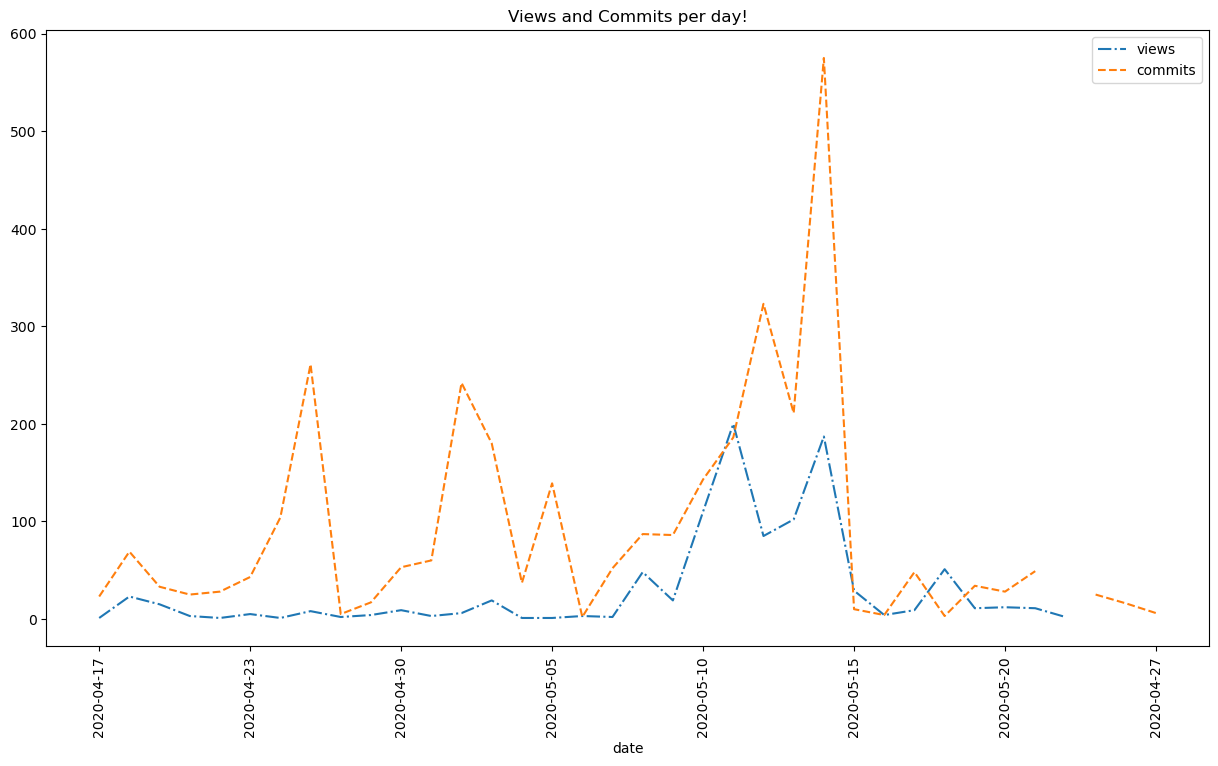

In [168]:
combiner_dataframe.set_index('date', inplace=True)
combiner_dataframe['view counts'].plot(figsize=(15, 8), linestyle='-.', label='views', legend=True)
combiner_dataframe['checker counts'].plot(figsize=(15, 8), linestyle='--', label='commits', legend=True, rot=90, title="Views and Commits per day!")

In [169]:
summed = combiner_dataframe['view counts'].sum()

print(summed // 150)

6.0


## The answer is 6.0.